### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [55]:
from imblearn.over_sampling import RandomOverSampler

### Step 2: Load Dataset

In [4]:
df = pd.read_csv('./data/BreastCancerWisconsin.csv')

In [5]:
df.shape

(569, 33)

In [6]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### Step 3: Exploaring Data

Basic Info

In [36]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [34]:
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Feature Distribution

In [16]:
feature_count = df['diagnosis'].value_counts()

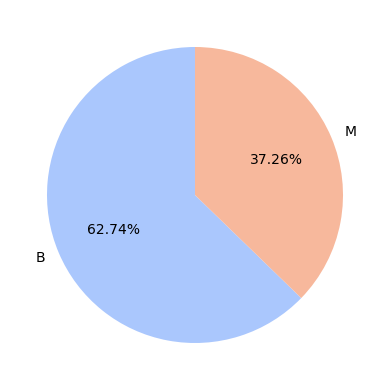

In [31]:
plt.figure(figsize=(6, 4))
plt.pie(
    feature_count,
    labels=feature_count.index,
    autopct='%.2f%%',
    startangle=90,
    colors=sns.color_palette('coolwarm', 2)
)
plt.tight_layout()

### Step 4: Feature Engineering

Handling Missing Value

In [33]:
df.drop(['Unnamed: 32', 'id'], axis=1, inplace=True)

Label Encoding

In [44]:
obj_list = df.select_dtypes(np.object_).columns

In [46]:
for col in obj_list:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

Normalization

In [45]:
num_list = df.select_dtypes(np.number).columns

In [49]:
scaler = StandardScaler()
for col in num_list:
    df[col] = scaler.fit_transform(df[[col]])

HeatMap

<Axes: >

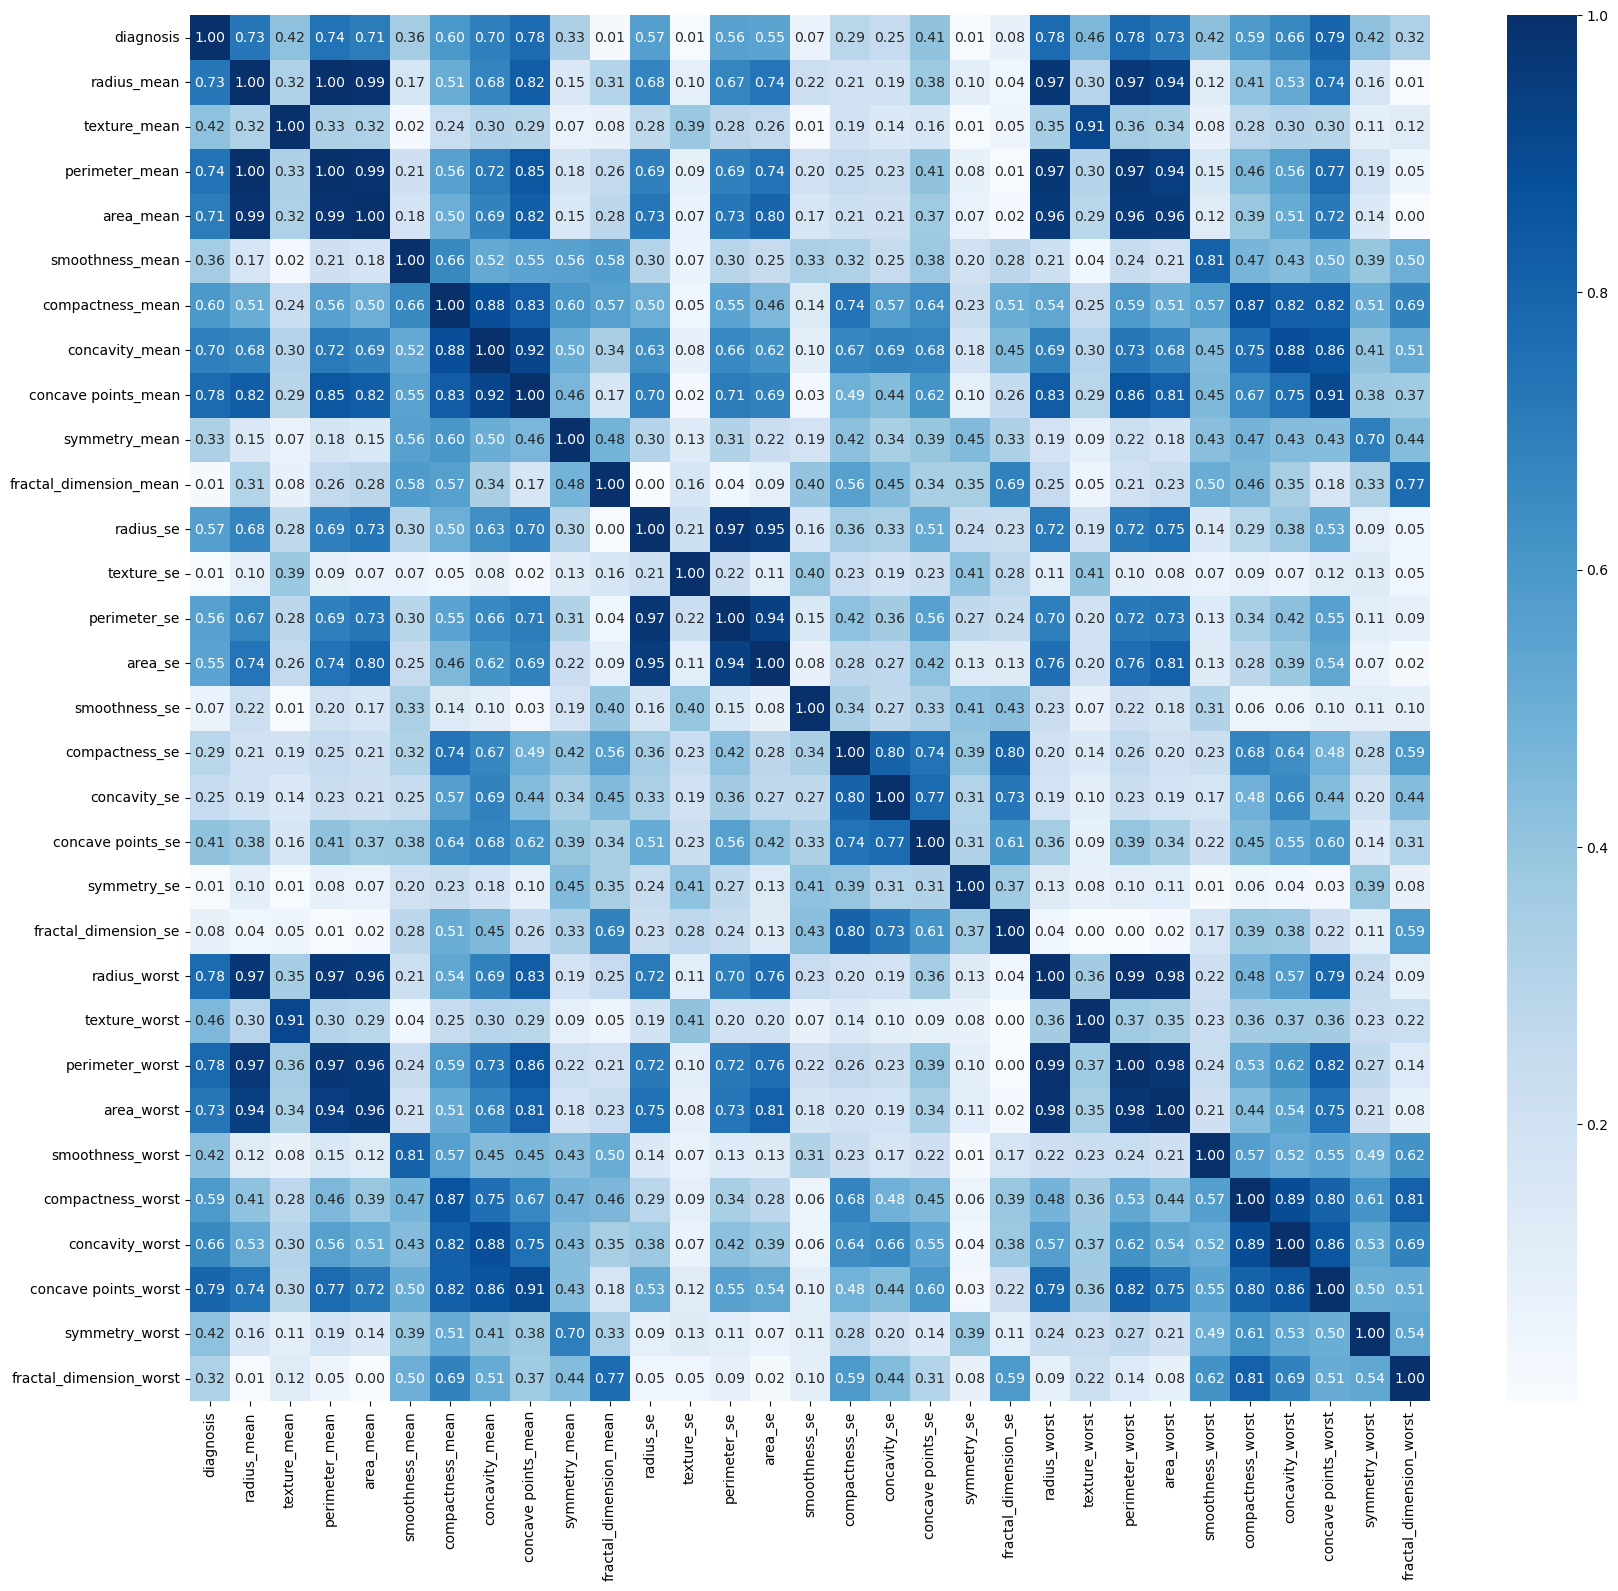

In [52]:
plt.figure(figsize=(20, 18))
sns.heatmap(
    df.corr().abs(),
    fmt='.2f',
    annot=True,
    cmap=plt.cm.Blues
)

### Step 5: Preparing Data

Preparing Features and Target

In [53]:
features = df.drop('diagnosis', axis=1)
target = df['diagnosis']

Split Data

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

Balanced Data

In [56]:
ros = RandomOverSampler()

In [57]:
X_train, y_train = ros.fit_resample(X_train, y_train)

### Step 6: Training & Evaluation Model

In [61]:
logreg = LogisticRegression()

In [62]:
stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [63]:
scores = cross_val_score(
    logreg,
    X_train,
    y_train,
    cv=stratified_kfold,
    scoring='accuracy',
    n_jobs=-1,
    error_score='raise'
)

In [67]:
print(f'Model: {logreg.__class__.__name__}')
print(f'Scores: {list(map(lambda x: round(x, 3), scores))}')
print(f'Mean Accuracy: {scores.mean():.3f}')

Model: LogisticRegression
Scores: [0.983, 0.965, 0.956, 0.991, 0.974]
Mean Accuracy: 0.974


In [68]:
logreg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Step 7: Evaluate Model

In [69]:
y_pred = logreg.predict(X_test)

In [73]:
accuracy = metrics.accuracy_score(y_test, y_pred)

In [74]:
print(f'Accuracy of the model is {100 * accuracy:.3f}%')

Accuracy of the model is 97.368%


In [75]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [76]:
cm = metrics.confusion_matrix(y_test, y_pred)

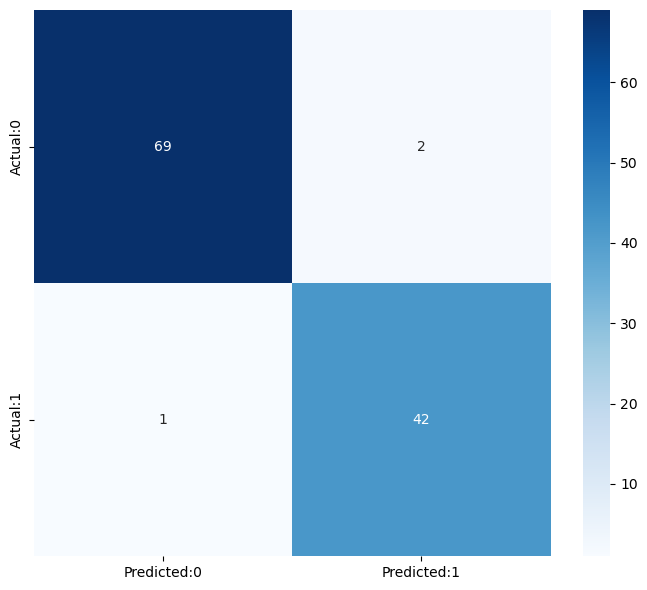

In [77]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    fmt='d',
    annot=True,
    cmap=plt.cm.Blues,
    xticklabels=['Predicted:0', 'Predicted:1'],
    yticklabels=['Actual:0', 'Actual:1'],
)
plt.tight_layout()